# Skewness Test

## Setup

In [15]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({
      'figure.dpi': 300,
      'text.usetex': True,
      'font.family': 'serif',
      'font.serif': ['Computer Modern Roman'],
      'font.size': 14,
  })
import seaborn as sns
import warnings
import scipy.stats as st
warnings.filterwarnings('ignore')

client = bigquery.Client(project="broadband-data")
print("Connected to BigQuery: broadband-data")

Connected to BigQuery: broadband-data


In [32]:
# group location-level data by project_id
proj_loc_query = """
SELECT
    proj.state,
    proj.project_id,
    proj.bead_support,
    COUNT(CASE WHEN loc.technology = 50 THEN 1 END) AS fiber_locations,
    COUNT(loc.project_id) AS total_locations,
    MAX(SAFE_CAST(loc.technology AS FLOAT64)) AS dominant_technology,
    AVG(CAST(loc.low_latency AS INT64)) AS avg_latency,
FROM `broadband-data.fp_approved.locations` loc
JOIN `broadband-data.fp_approved.deployment_projects` proj USING (project_id)
GROUP BY proj.state, proj.project_id, proj.bead_support
"""
df_locations = client.query(proj_loc_query).to_dataframe()
print(f"Location aggregates: {df_locations.shape}")
df_locations.head()

Location aggregates: (5224, 7)


,state,project_id,bead_support,fiber_locations,total_locations,dominant_technology,avg_latency
0,DE,CM61-BEAD-DE-Verizon,9597115.0,2327,2327,50.0,1.0
1,CT,CM61-BEAD-CT-009-1,193291.0,11,13,50.0,1.0
2,HI,CM61-BEAD-HI-LEO-HAWAII,637200.0,0,1062,61.0,1.0
3,HI,CM61-BEAD-HI-LEO-MAUI,78000.0,0,130,61.0,1.0
4,HI,CM61-BEAD-HI-UNDER-HAWAII,18180750.0,4146,4146,50.0,1.0


In [63]:
from scipy.stats import percentileofscore
df_locations['percentile_loc'] = [round(percentileofscore(df_locations['total_locations'], score, kind='rank')) for score in df_locations['total_locations']]
df_locations['percentile_funding'] = [round(percentileofscore(df_locations['avg_bead_support'], score, kind='rank')) for score in df_locations['avg_bead_support']]
df_fiber = df_locations[df_locations['fiber_locations'] > 0].copy()

In [12]:
perc_funded_avg = df_locations.groupby('percentile_funding')['avg_bead_support'].mean().reset_index()
perc_funded = df_locations.groupby('percentile_loc')['bead_support'].mean().reset_index()

In [17]:
avg_bead_support_across_all = df_locations['avg_bead_support'].mean()

## Average BEAD Support by Location Percentile

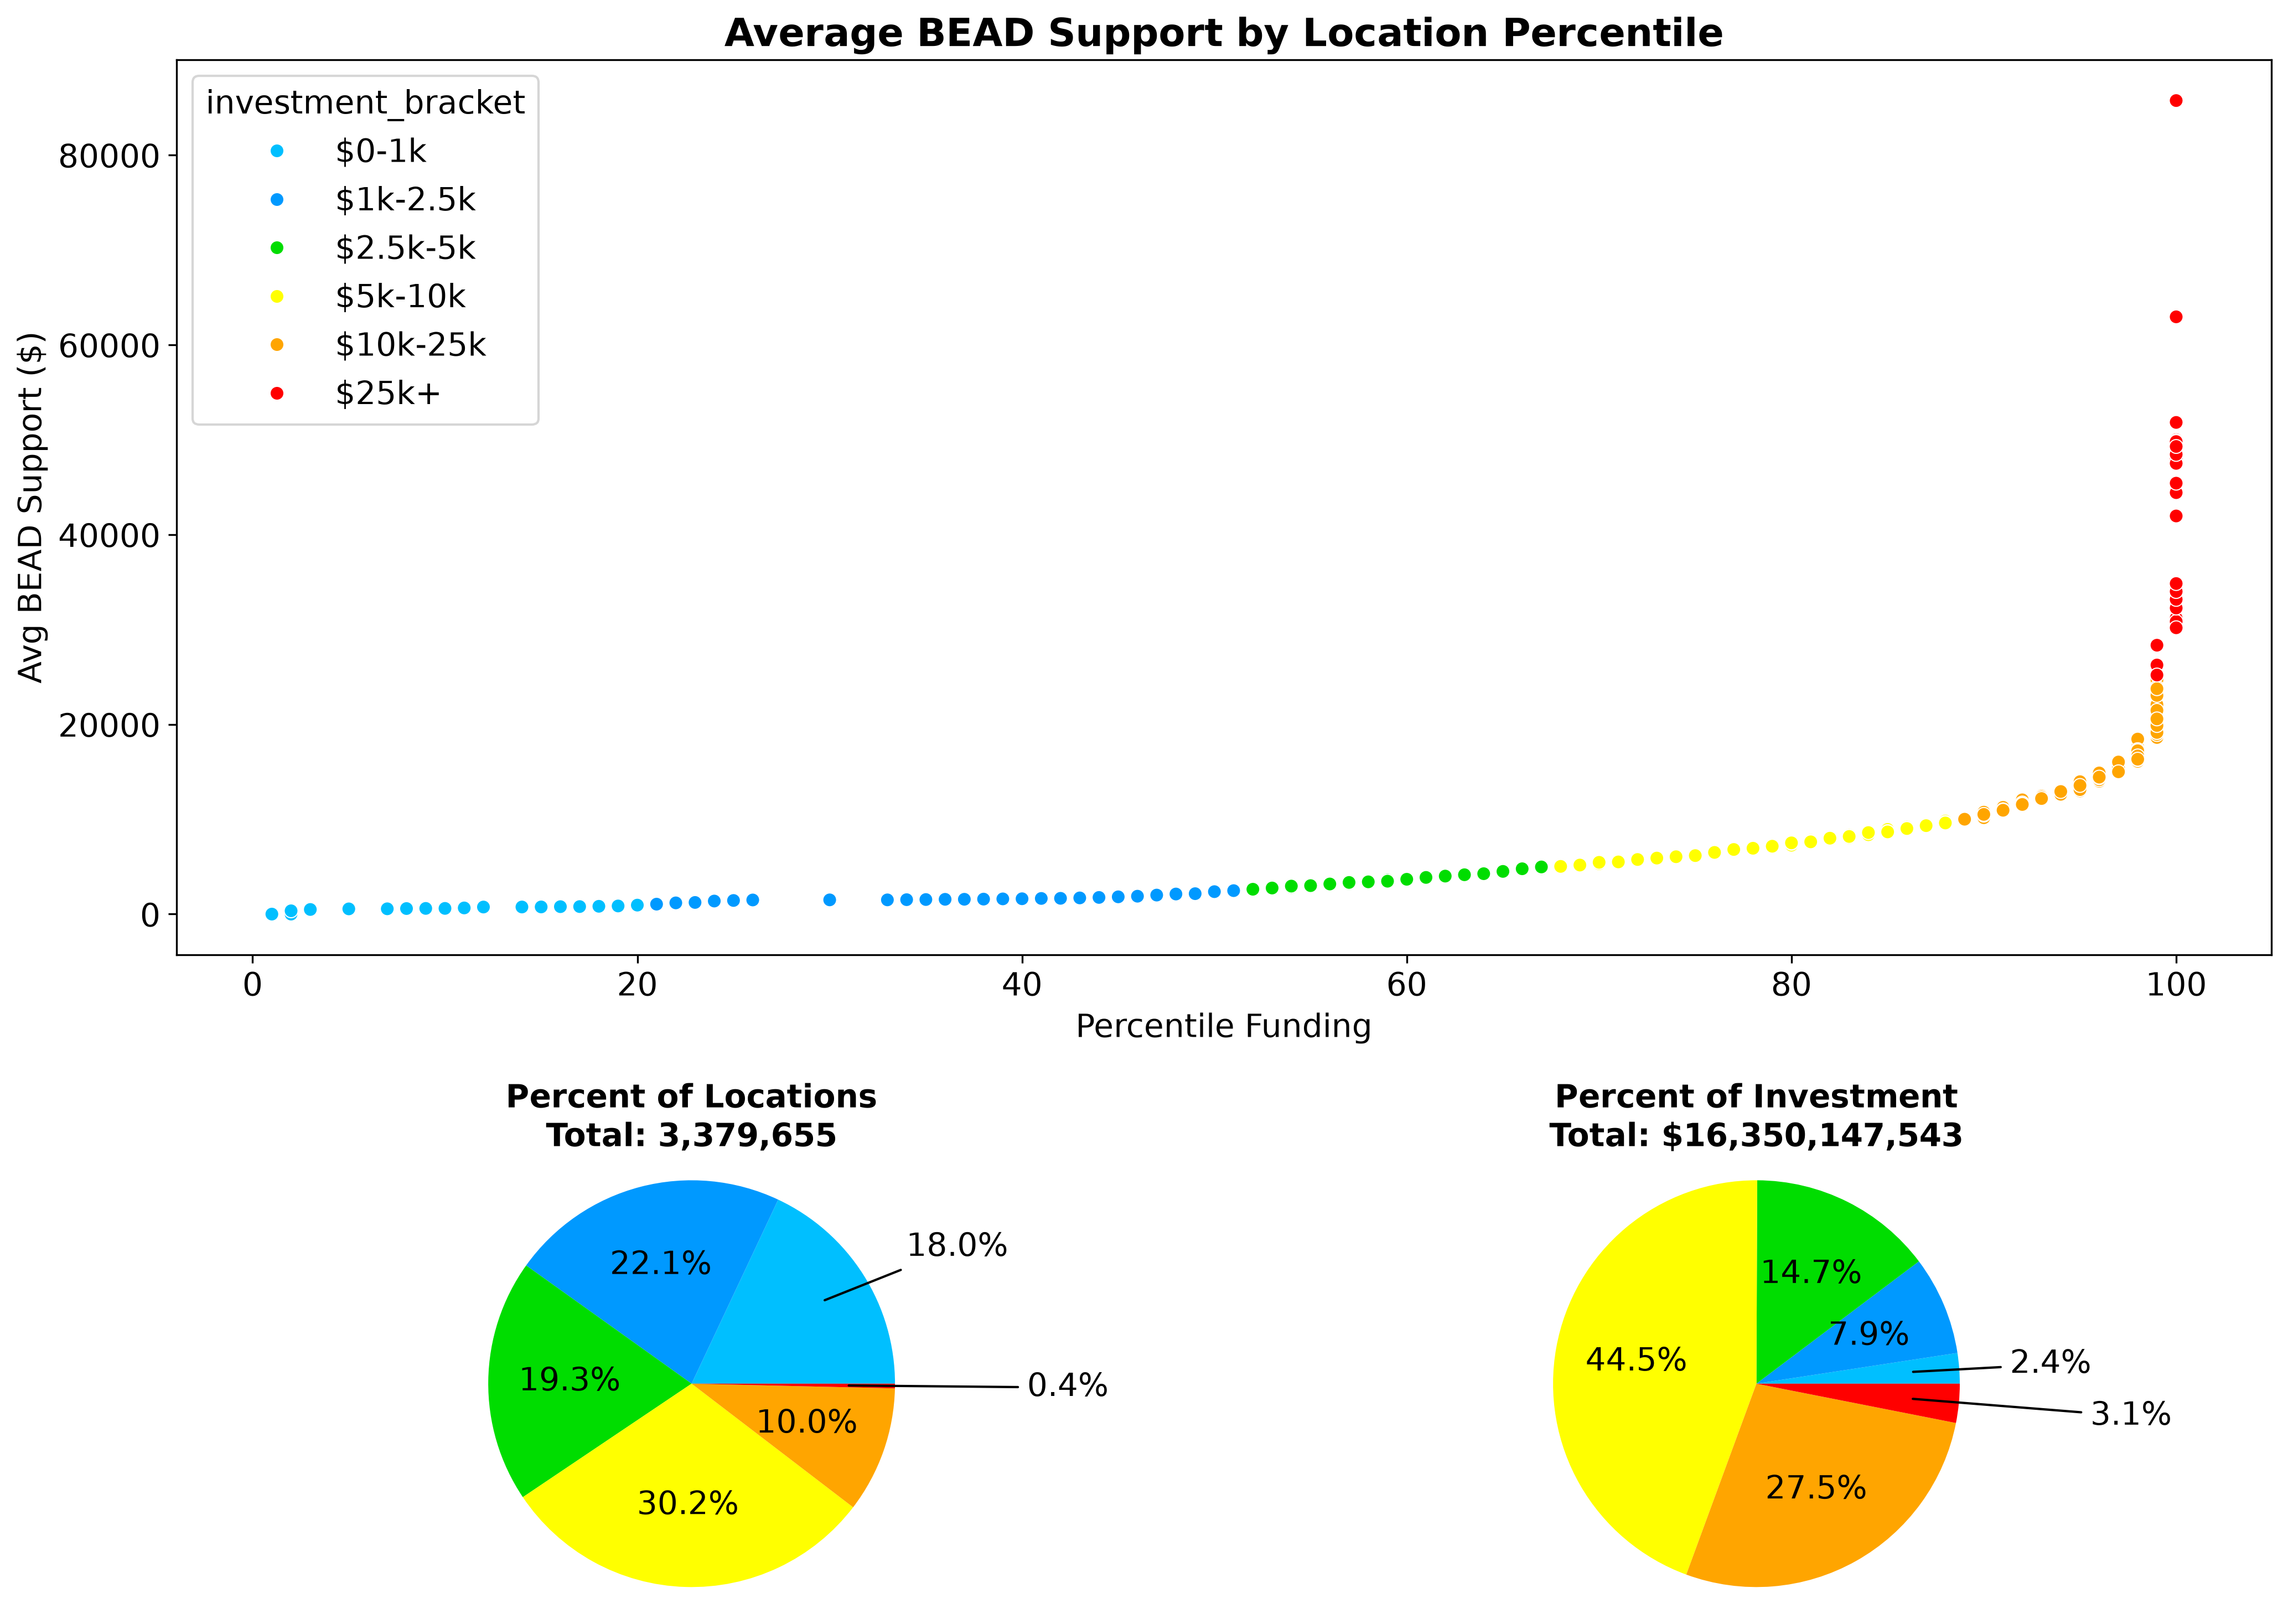

In [82]:
import matplotlib.gridspec as gridspec
import matplotlib
import seaborn as sns

matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']

bracket_order = ['$0-1k', '$1k-2.5k', '$2.5k-5k', '$5k-10k', '$10k-25k', '$25k+']
bracket_colors = {
    '$0-1k': '#00BFFF', '$1k-2.5k': '#0099FF', '$2.5k-5k': '#00DD00',
    '$5k-10k': '#FFFF00', '$10k-25k': '#FFA500', '$25k+': '#FF0000'
}

def assign_bracket(value):
    if value < 1000: return '$0-1k'
    elif value < 2500: return '$1k-2.5k'
    elif value < 5000: return '$2.5k-5k'
    elif value < 10000: return '$5k-10k'
    elif value < 25000: return '$10k-25k'
    else: return '$25k+'

df_locations['investment_bracket'] = df_locations['avg_bead_support'].apply(assign_bracket)

# Compute pie data (weighted by locations)
location_by_bracket = df_locations.groupby('investment_bracket')['total_locations'].sum().reindex(bracket_order)
investment_by_bracket = df_locations.groupby('investment_bracket')['bead_support'].sum().reindex(bracket_order)
location_pct = location_by_bracket / location_by_bracket.sum() * 100
investment_pct = investment_by_bracket / investment_by_bracket.sum() * 100
colors = [bracket_colors[b] for b in bracket_order]

# Layout
fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[2, 1])

ax_scatter = fig.add_subplot(gs[0, :])  # spans both columns
ax_pie1 = fig.add_subplot(gs[1, 0])
ax_pie2 = fig.add_subplot(gs[1, 1])

# Scatter
palette = {b: bracket_colors[b] for b in bracket_order}
sns.scatterplot(
    data=df_locations, ax=ax_scatter,
    x='percentile_funding', y='avg_bead_support',
    hue='investment_bracket', hue_order=bracket_order, palette=palette
)
ax_scatter.set_title('Average BEAD Support by Location Percentile', fontweight='bold')
ax_scatter.set_xlabel('Percentile Funding')
ax_scatter.set_ylabel('Avg BEAD Support ($)')

# Pie 1: locations
custom_distances = [1.25, 0.6, 0.6, 0.6, 0.6, 1.65]
wedges, _, autotexts = ax_pie1.pie(location_pct, autopct='%1.1f%%', colors=colors)
kw = dict(arrowprops=dict(arrowstyle="-"), va="center")
ax_pie1.set_title(f'Percent of Locations\nTotal: {location_by_bracket.sum():,.0f}', fontweight='bold', fontsize=14)
for wedge, text_obj, desired_dist in zip(wedges, autotexts, custom_distances):
    if desired_dist > 1:
        text_obj.set_visible(False)
        
        ang = np.deg2rad((wedge.theta1 + wedge.theta2) / 2)
        x, y = np.cos(ang), np.sin(ang)
        horizontalalignment = "center" if abs(x) < abs(y) else "right" if x < 0 else "left"
        pct_text = f'{text_obj.get_text()}'  # reuse the formatted pct string
        ax_pie1.annotate(pct_text, xy=(0.75*x, 0.75*y), xytext=(desired_dist*x, desired_dist*y),
                         horizontalalignment=horizontalalignment, **kw)
    else:
        angle = np.arctan2(*text_obj.get_position()[::-1])
        text_obj.set_position((desired_dist * np.cos(angle), desired_dist * np.sin(angle)))

ax_pie1.axis('equal')

# Pie 2: investment
custom_distances = [1.25, 0.6, 0.6, 0.6, 0.6, 1.65]
wedges, _, autotexts = ax_pie2.pie(investment_pct, autopct='%1.1f%%', colors=colors)
ax_pie2.set_title(f'Percent of Investment\nTotal: ${investment_by_bracket.sum():,.0f}', fontweight='bold', fontsize=14)

kw = dict(arrowprops=dict(arrowstyle="-"), va="center")
ax_pie2.set_title(f'Percent of Investment\nTotal: ${investment_by_bracket.sum():,.0f}', fontweight='bold', fontsize=14)
for wedge, text_obj, desired_dist in zip(wedges, autotexts, custom_distances):
    if desired_dist > 1:
        text_obj.set_visible(False)
        
        ang = np.deg2rad((wedge.theta1 + wedge.theta2) / 2)
        x, y = np.cos(ang), np.sin(ang)
        horizontalalignment = "center" if abs(x) < abs(y) else "right" if x < 0 else "left"
        pct_text = f'{text_obj.get_text()}'  # reuse the formatted pct string
        ax_pie2.annotate(pct_text, xy=(0.75*x, 0.75*y), xytext=(desired_dist*x, desired_dist*y),
                         horizontalalignment=horizontalalignment, **kw)
    else:
        angle = np.arctan2(*text_obj.get_position()[::-1])
        text_obj.set_position((desired_dist * np.cos(angle), desired_dist * np.sin(angle)))

ax_pie2.axis('equal')

plt.tight_layout()
plt.savefig('bead_support_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

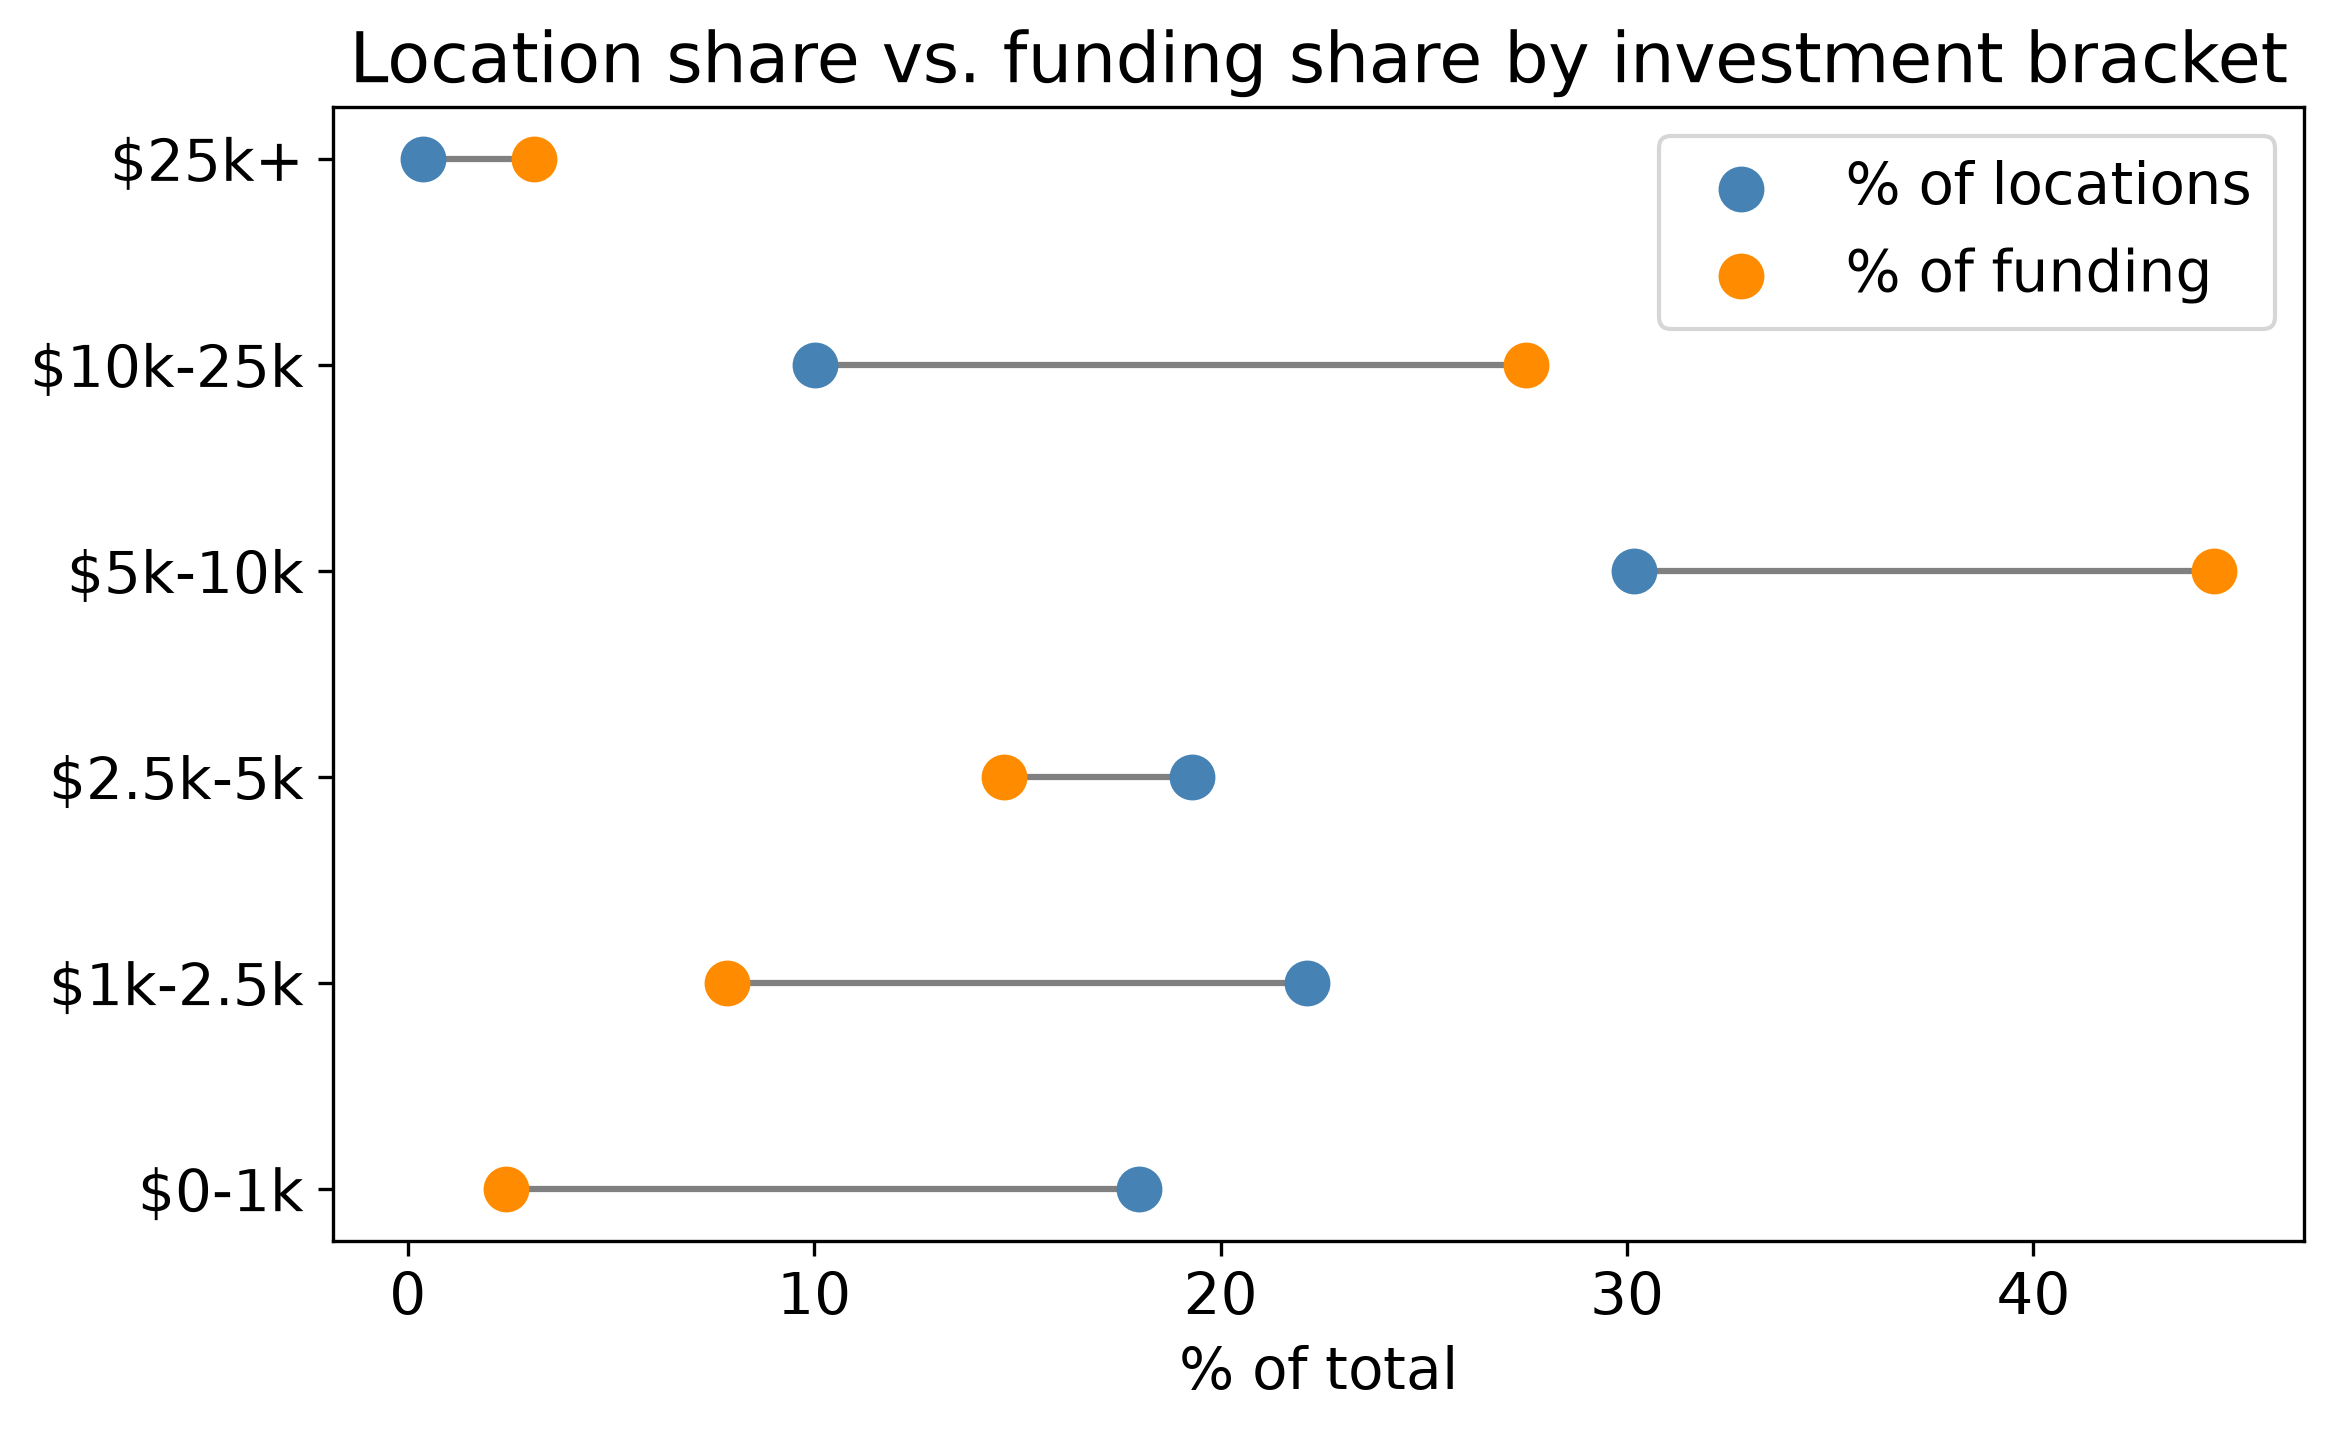

In [83]:
fig, ax = plt.subplots(figsize=(8, 5))

y_pos = range(len(bracket_order))
for i, bracket in enumerate(bracket_order):
    loc = location_pct[bracket]
    inv = investment_pct[bracket]
    ax.plot([loc, inv], [i, i], color='gray', zorder=1, linewidth=1.5)
    ax.scatter(loc, i, color='steelblue', s=100, zorder=2, label='% of locations' if i == 0 else None)
    ax.scatter(inv, i, color='darkorange', s=100, zorder=2, label='% of funding' if i == 0 else None)

ax.set_yticks(y_pos)
ax.set_yticklabels(bracket_order)
ax.set_xlabel('% of total')
ax.legend()
ax.set_title('Location share vs. funding share by investment bracket')
plt.tight_layout()

## [Fiber-only] Average BEAD Support by Location Percentile

In [73]:
df_all = df_locations.copy()  # original — all projects
df_fiber_only = df_locations[df_locations['fiber_locations'] == df_locations['total_locations']].copy()
# then recompute percentile_funding for df_fiber_only separately
df_fiber_only['percentile_funding'] = [
    round(percentileofscore(df_fiber_only['fiber_locations'], score, kind='rank'))
    for score in df_fiber_only['fiber_locations']
]

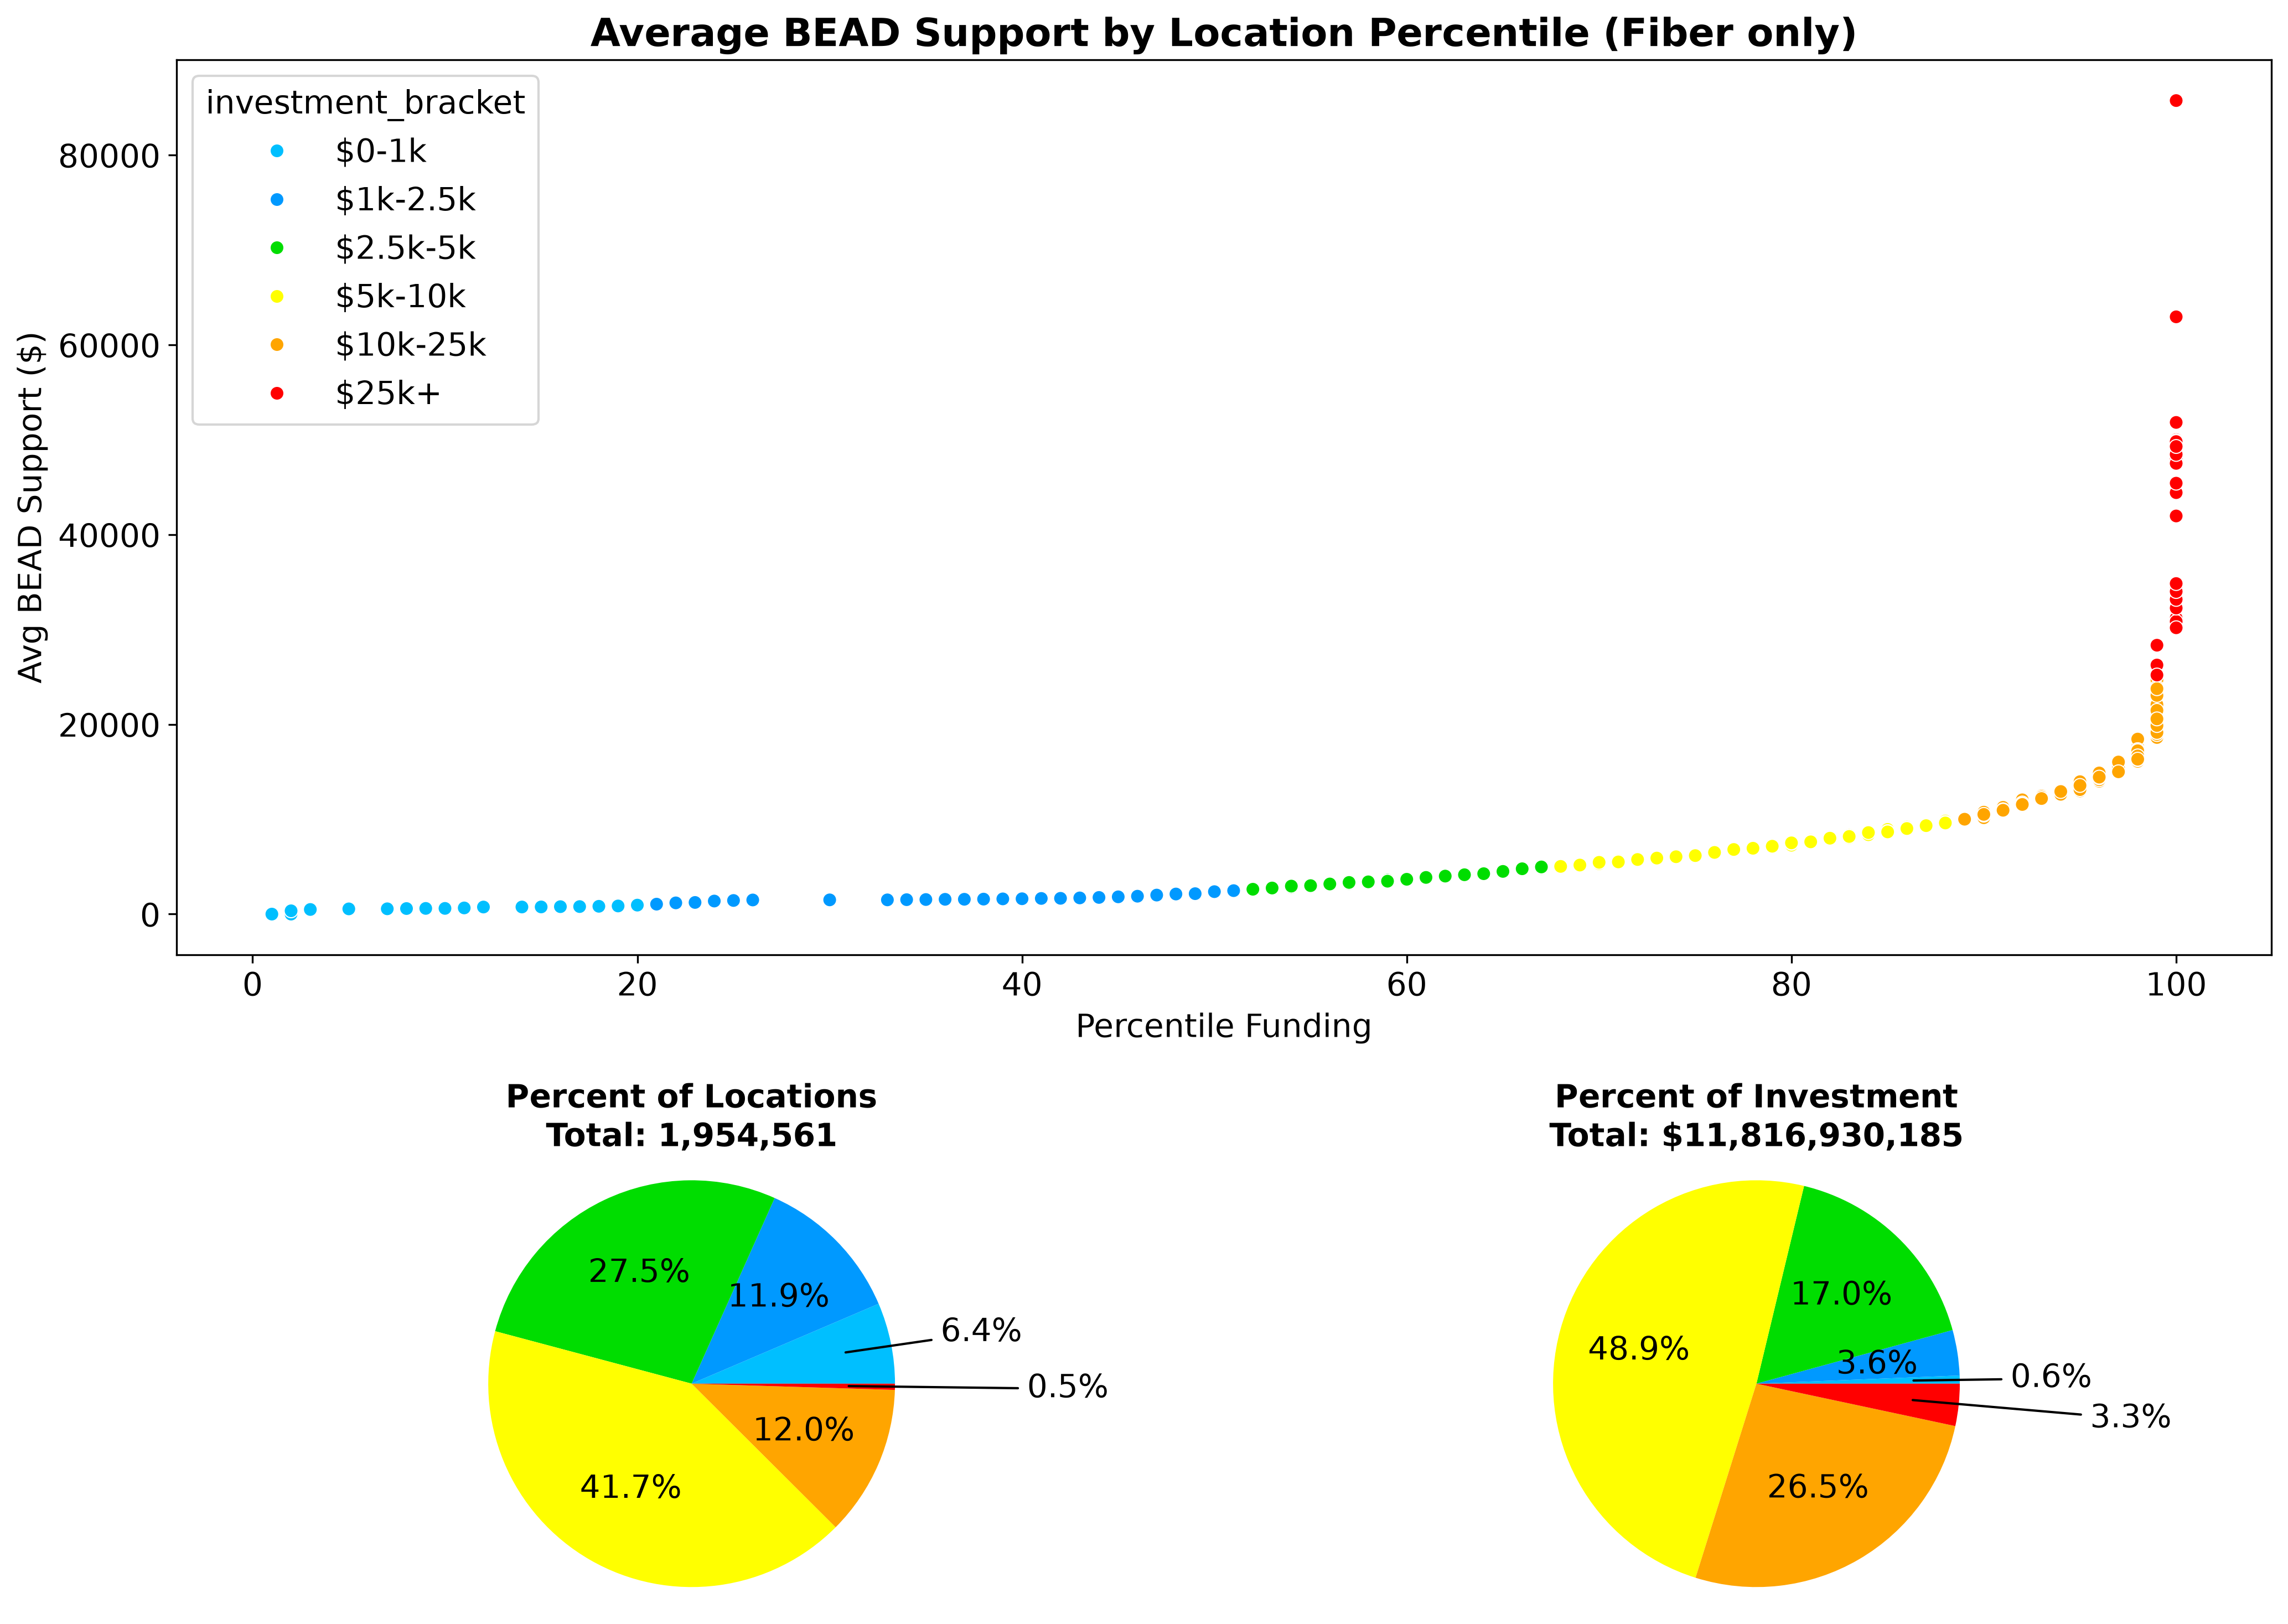

In [75]:
import matplotlib.gridspec as gridspec
import matplotlib
import seaborn as sns

matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']

bracket_order = ['$0-1k', '$1k-2.5k', '$2.5k-5k', '$5k-10k', '$10k-25k', '$25k+']
bracket_colors = {
    '$0-1k': '#00BFFF', '$1k-2.5k': '#0099FF', '$2.5k-5k': '#00DD00',
    '$5k-10k': '#FFFF00', '$10k-25k': '#FFA500', '$25k+': '#FF0000'
}

def assign_bracket(value):
    if value < 1000: return '$0-1k'
    elif value < 2500: return '$1k-2.5k'
    elif value < 5000: return '$2.5k-5k'
    elif value < 10000: return '$5k-10k'
    elif value < 25000: return '$10k-25k'
    else: return '$25k+'

df_fiber_only['investment_bracket'] = df_fiber_only['avg_bead_support'].apply(assign_bracket)

# Compute pie data (weighted by locations)
location_by_bracket = df_fiber_only.groupby('investment_bracket')['fiber_locations'].sum().reindex(bracket_order)
investment_by_bracket = df_fiber_only.groupby('investment_bracket')['bead_support'].sum().reindex(bracket_order)
location_pct = location_by_bracket / location_by_bracket.sum() * 100
investment_pct = investment_by_bracket / investment_by_bracket.sum() * 100
colors = [bracket_colors[b] for b in bracket_order]

# Layout
fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[2, 1])

ax_scatter = fig.add_subplot(gs[0, :])  # spans both columns
ax_pie1 = fig.add_subplot(gs[1, 0])
ax_pie2 = fig.add_subplot(gs[1, 1])

# Scatter
palette = {b: bracket_colors[b] for b in bracket_order}
sns.scatterplot(
    data=df_locations, ax=ax_scatter,
    x='percentile_funding', y='avg_bead_support',
    hue='investment_bracket', hue_order=bracket_order, palette=palette
)
ax_scatter.set_title('Average BEAD Support by Location Percentile (Fiber only)', fontweight='bold')
ax_scatter.set_xlabel('Percentile Funding')
ax_scatter.set_ylabel('Avg BEAD Support ($)')

# Pie 1: locations
custom_distances = [1.25, 0.6, 0.6, 0.6, 0.6, 1.65]
wedges, _, autotexts = ax_pie1.pie(location_pct, autopct='%1.1f%%', colors=colors)
kw = dict(arrowprops=dict(arrowstyle="-"), va="center")
ax_pie1.set_title(f'Percent of Locations\nTotal: {location_by_bracket.sum():,.0f}', fontweight='bold', fontsize=14)
for wedge, text_obj, desired_dist in zip(wedges, autotexts, custom_distances):
    if desired_dist > 1:
        text_obj.set_visible(False)
        
        ang = np.deg2rad((wedge.theta1 + wedge.theta2) / 2)
        x, y = np.cos(ang), np.sin(ang)
        horizontalalignment = "center" if abs(x) < abs(y) else "right" if x < 0 else "left"
        pct_text = f'{text_obj.get_text()}'  # reuse the formatted pct string
        ax_pie1.annotate(pct_text, xy=(0.75*x, 0.75*y), xytext=(desired_dist*x, desired_dist*y),
                         horizontalalignment=horizontalalignment, **kw)
    else:
        angle = np.arctan2(*text_obj.get_position()[::-1])
        text_obj.set_position((desired_dist * np.cos(angle), desired_dist * np.sin(angle)))

ax_pie1.axis('equal')

# Pie 2: investment
custom_distances = [1.25, 0.6, 0.6, 0.6, 0.6, 1.65]
wedges, _, autotexts = ax_pie2.pie(investment_pct, autopct='%1.1f%%', colors=colors)
ax_pie2.set_title(f'Percent of Investment\nTotal: ${investment_by_bracket.sum():,.0f}', fontweight='bold', fontsize=14)

kw = dict(arrowprops=dict(arrowstyle="-"), va="center")
ax_pie2.set_title(f'Percent of Investment\nTotal: ${investment_by_bracket.sum():,.0f}', fontweight='bold', fontsize=14)
for wedge, text_obj, desired_dist in zip(wedges, autotexts, custom_distances):
    if desired_dist > 1:
        text_obj.set_visible(False)
        
        ang = np.deg2rad((wedge.theta1 + wedge.theta2) / 2)
        x, y = np.cos(ang), np.sin(ang)
        horizontalalignment = "center" if abs(x) < abs(y) else "right" if x < 0 else "left"
        pct_text = f'{text_obj.get_text()}'  # reuse the formatted pct string
        ax_pie2.annotate(pct_text, xy=(0.75*x, 0.75*y), xytext=(desired_dist*x, desired_dist*y),
                         horizontalalignment=horizontalalignment, **kw)
    else:
        angle = np.arctan2(*text_obj.get_position()[::-1])
        text_obj.set_position((desired_dist * np.cos(angle), desired_dist * np.sin(angle)))

ax_pie2.axis('equal')

plt.tight_layout()
plt.savefig('bead_support_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Funding bracket by technology

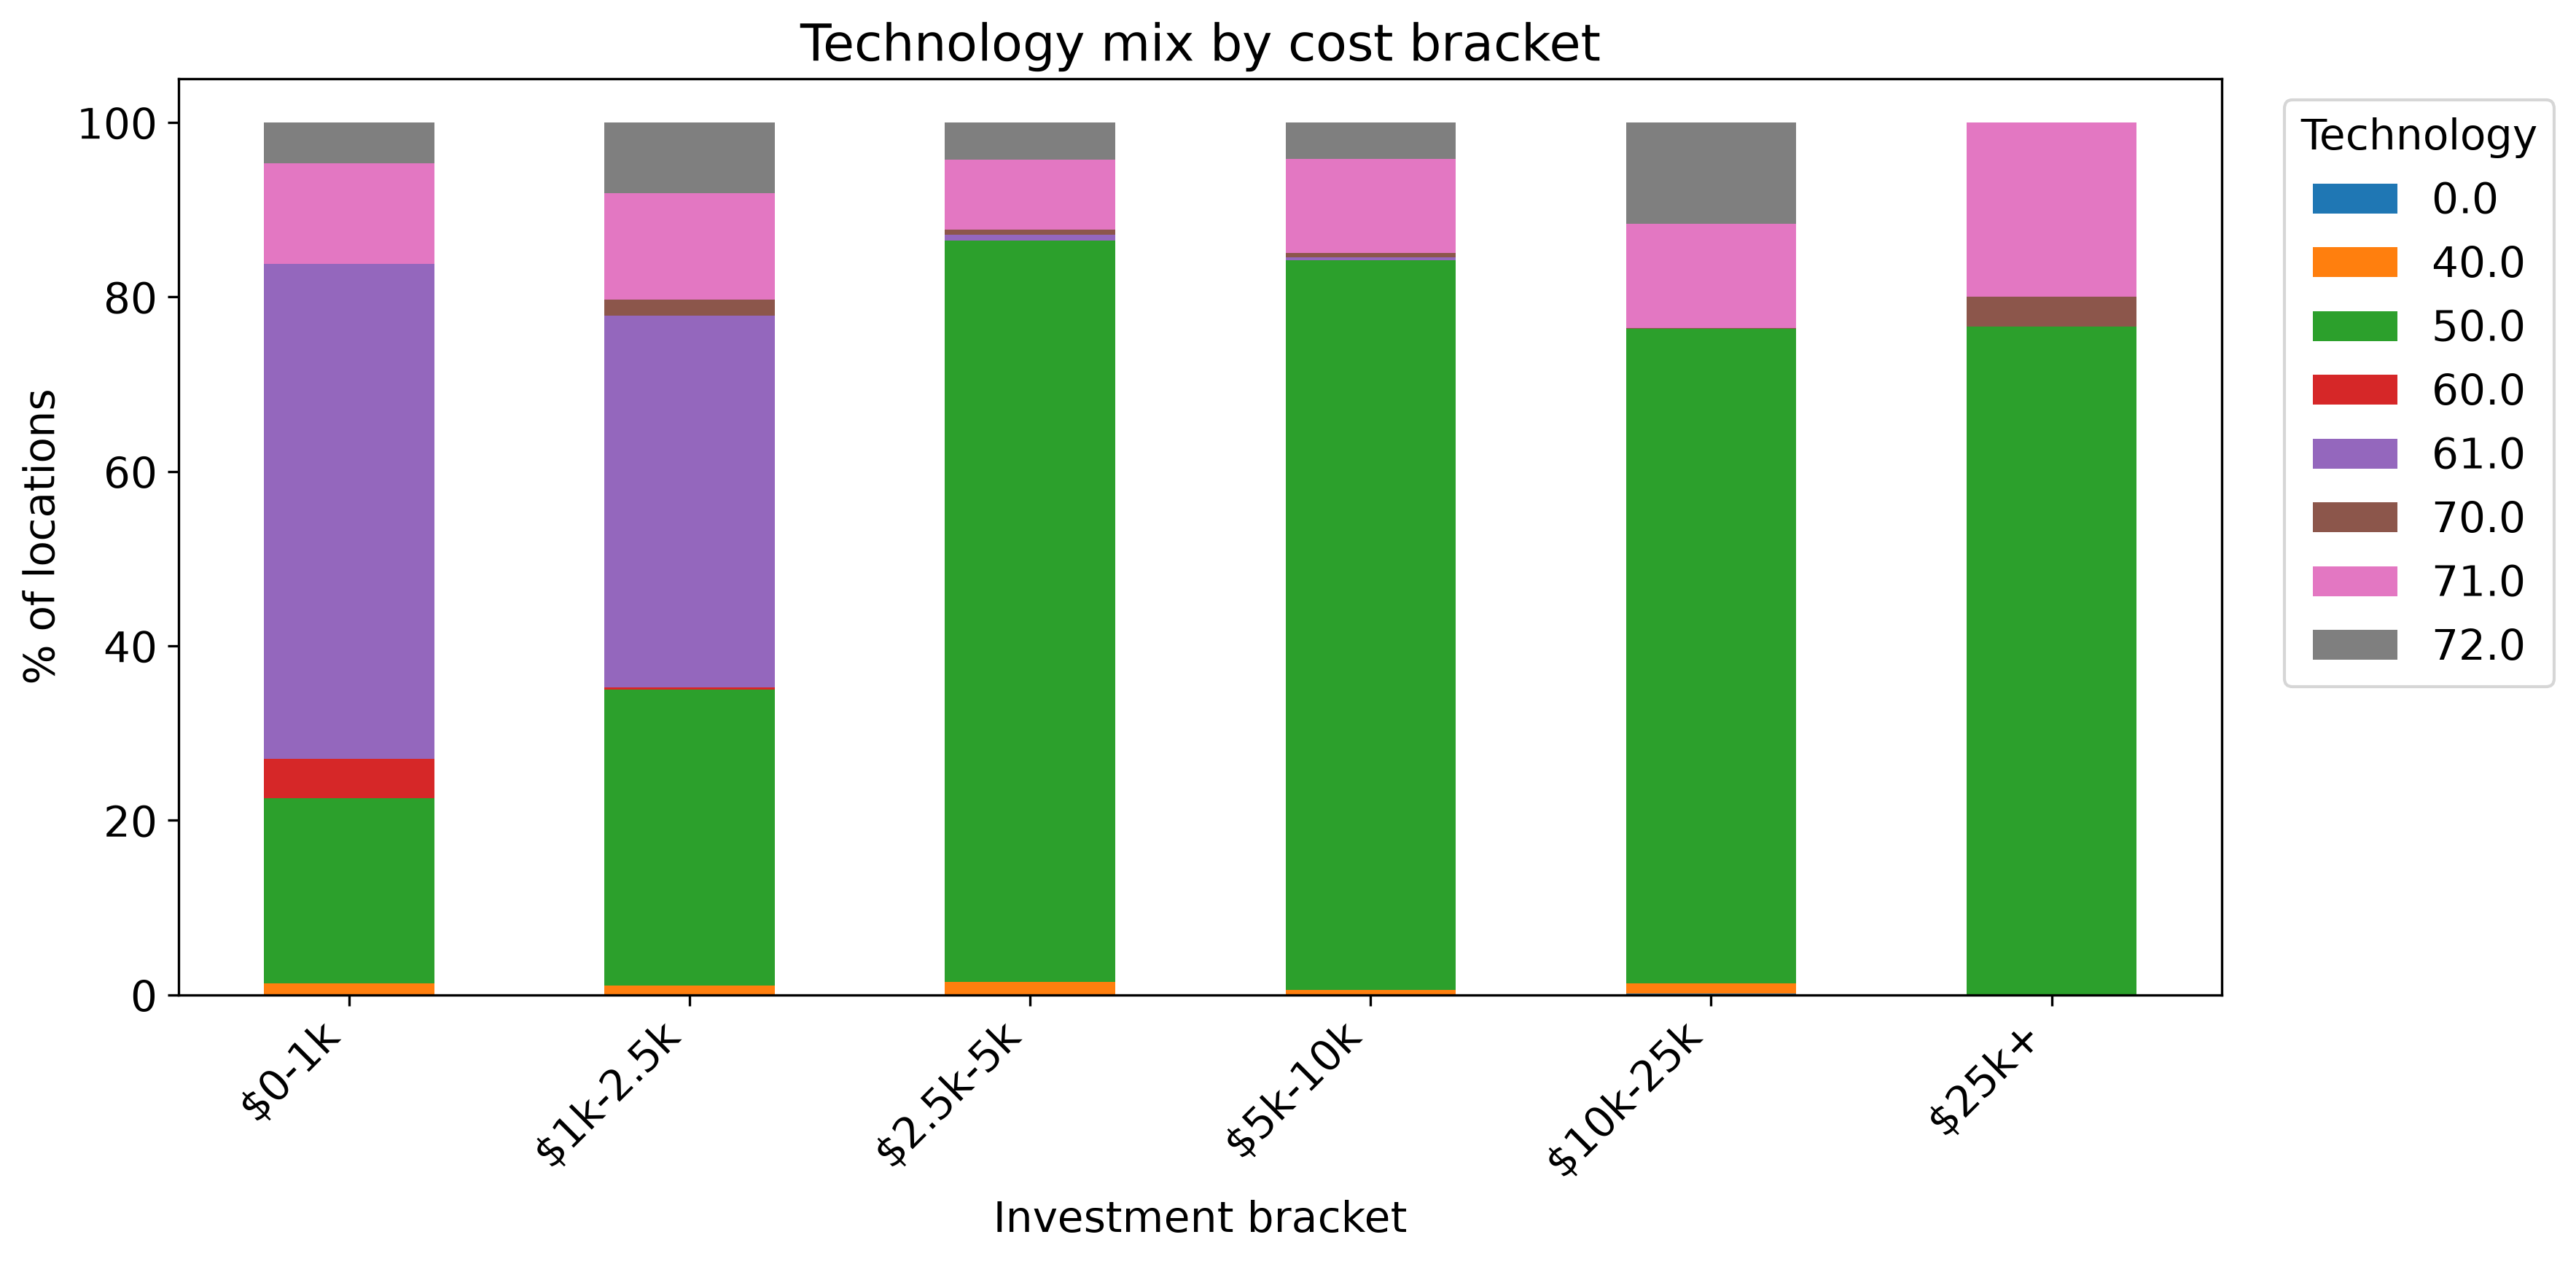

In [80]:
# For each bracket, what % of locations are each technology?
tech_by_bracket = (
    df_locations.groupby(['investment_bracket', 'dominant_technology'])['total_locations']
    .sum()
    .unstack(fill_value=0)
)
tech_by_bracket = tech_by_bracket.reindex(bracket_order)
tech_pct = tech_by_bracket.div(tech_by_bracket.sum(axis=1), axis=0) * 100

tech_pct.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.ylabel('% of locations')
plt.xlabel('Investment bracket')
plt.xticks(ha='right', rotation=45)
plt.title('Technology mix by cost bracket')
plt.legend(title='Technology', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()